# Climate variables for Lake Poopó region using ERA5-Land reanalysis (1950-2025)

This notebook extracts and visualizes key climate variables for the Lake Poopó region in Bolivia using the [ERA5-Land monthly reanalysis dataset](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-monthly-means?tab=overview), accessed through the Copernicus Climate Data Store (CDS) API.

Extracted variables:

- 2m air surface temperature
- Total precipitation
- Potential evaporation

In [1]:
import sys
from pathlib import Path
import cdsapi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
from src.lakeclimate import cds

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles

project_root = Path.cwd()
data_raw = project_root / "data_cds" / "raw"

# Study area

The analysis is restricted to the bounding box covering the lake and immediate surroundings. The satellite map below shows the Lake Poopó region.

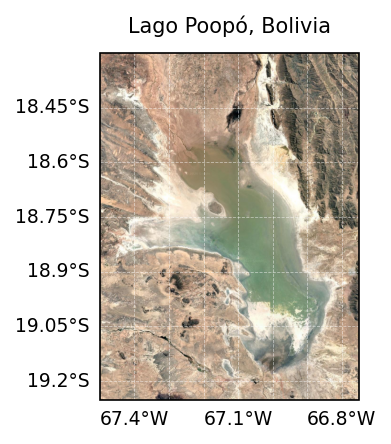

In [2]:
# CDS API expect the coordinate order: [North, West, South, East]
poopo_region = [-18.30, -67.50, -19.25, -66.75] 

north, west, south, east = poopo_region

fig = plt.figure(figsize=(4, 3), dpi=150)

tiler = GoogleTiles(style="satellite")
ax = plt.axes(projection=tiler.crs)
ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
ax.add_image(tiler, 11)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    color="white",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

plt.title("Lago Poopó, Bolivia", fontsize=10, pad=10)
path_to_save = project_root / "figures" / "poopo_region_map..png"
plt.savefig(path_to_save,dpi=150,bbox_inches="tight",pad_inches=0.1)
plt.show()


# Climate variables analysis and visualization

## Air temperature at 2m

Below, you can see how to download the monthly mean (`2m_temperature`) variable from 1950-2025 for the Poopó bounding box. 
The download is commented out below because the NetCDF file is already cached locally. To
re-download, uncomment the `client.retrieve(...)` call (requires a valid CDS API key).

### Data download

In [6]:

target_nc = data_raw / "era5_land_2m_temperature_poopo_monthly.nc"
cds_dataset = "reanalysis-era5-land-monthly-means"

start_year = 1950
end_year = 2025 

cds_request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable": "2m_temperature",
    "year": [str(y) for y in range(start_year, end_year + 1)],
    "month": [f"{m:02d}" for m in range(1, 13)],
    "time": "00:00",
    "format": "netcdf",
    "download_format": "unarchived",
    "area": poopo_region,  
}
#client = cdsapi.Client()
#client.retrieve(cds_dataset, cds_request, str(target_nc))
print(f"Already downloaded: {target_nc.exists()}")

Already downloaded: True


## Data processing

The raw ERA5-Land grid covers several pixels over the lake region. First, I computed an area-weighted spatial mean to report to report a single representative monthly time series.

Second, the temperature is converted from Kelvin to Celsius and aggregated to annual means, keeping only years with all 12 months present.



In [7]:
data_processed = project_root/ "data_cds" / "processed"

ds = xr.open_dataset(target_nc)
var_name = list(ds.data_vars)[0]

monthly_mean_K = cds.area_weighted_mean(ds, var_name)
monthly_mean_C = monthly_mean_K - 273.15
monthly_df = monthly_mean_C.to_dataframe(name="t2m_C").reset_index()

monthly_df = monthly_df.rename(columns={"valid_time": "date"})
monthly_df = monthly_df[["date", "t2m_C"]].sort_values("date")
monthly_df.to_csv(data_processed / "era5_land_t2m_poopo_monthly.csv", index=False)
monthly_df["date"] = pd.to_datetime(monthly_df["date"])
monthly_df["year"] = monthly_df["date"].dt.year

# Keep only complete years (12 months)
annual_counts = monthly_df.groupby("year").size()
complete_years = annual_counts[annual_counts == 12].index

annual_df = (
    monthly_df[monthly_df["year"].isin(complete_years)]
    .groupby("year")["t2m_C"]
    .mean()
    .reset_index()
)
print(annual_df.head())
annual_df.to_csv(data_processed / "era5_land_t2m_poopo_annual.csv", index=False)

   year     t2m_C
0  1950  7.493635
1  1951  7.475684
2  1952  7.641961
3  1953  7.749628
4  1954  7.571948


## Annual temperature anomaly

To spot the long-term warming, I computed the annual temperature anomalies relative to the reference period (1951-1980). 

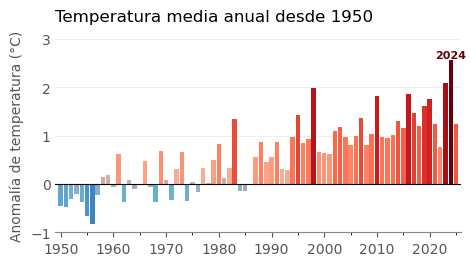

In [8]:
baseline = annual_df[(annual_df["year"] >= 1951) & (annual_df["year"] <= 1980)]
baseline_mean_T = baseline["t2m_C"].mean()
annual_df["anomaly_C"] = annual_df["t2m_C"] - baseline_mean_T
anomalies = annual_df["anomaly_C"].values

abs_max = max(abs(anomalies.min()), abs(anomalies.max()))
hawkins_colors = [
    "#08306b", "#08519c", "#2171b5", "#6baed6",   # blues (cold)
    "#fcae91", "#fb6a4a", "#cb181d", "#67000d"    # reds (warm)
]
cmap = LinearSegmentedColormap.from_list("warming_stripes", hawkins_colors, N=256)
norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)


fig,ax2 = plt.subplots( figsize=(5, 3))

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_alpha(0)
ax2.spines['bottom'].set_color("#888")

ax2.set_axisbelow(True)
ax2.tick_params(axis='y', length=0)
ax2.tick_params(colors="#555")

ax2.bar(annual_df["year"], annual_df["anomaly_C"], color=[cmap(norm(a)) for a in annual_df["anomaly_C"].values], width=0.85, edgecolor="none")
ax2.set_ylabel("Anomalía de temperatura (°C)",fontsize = 10,color="#555")
ax2.axhline(0, color="black", linewidth=0.8)

ax2.xaxis.set_minor_locator(AutoMinorLocator(2)) 
ax2.yaxis.grid(True, linewidth=0.8, color="#eee")

ax2.set_ylim(-1,3)
plt.xlim(1949,2026)

ax2.set_title("Temperatura media anual desde 1950",loc="left", y=1.05)

# Highlight the hottest year
hot_temp = annual_df["anomaly_C"].max()
hot_year = annual_df["year"][annual_df["anomaly_C"].idxmax()]
ax2.text(
    hot_year,
    hot_temp +0.05,
    str(hot_year),
    color="#67000d",
    fontsize=8,
    fontweight='bold',
    ha='center'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
path_to_save = project_root / "figures" / "2mt_anomaly_1951-1980_bl_poopo.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()

Each bar shows how much warmer or cooler that year
was compared to the reference period. The hottest year on record is labeled on the chart.

## Absolute annual temperature

Below, I plot the raw annual mean temperature (°C) to give an
intuitive sense of the actual thermal regime at Lake Poopó region. 

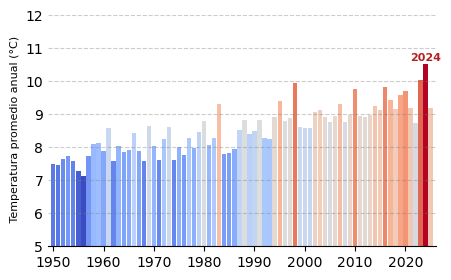

In [ ]:

norm = mpl.colors.Normalize(vmin=annual_df["t2m_C"].min(), vmax=annual_df["t2m_C"].max())

cmap = mpl.colormaps["coolwarm"]
colors = cmap(norm(annual_df["t2m_C"]))

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.bar(annual_df["year"] , annual_df["t2m_C"] , color=colors, width=0.85)
ax1.set_ylabel(f" Temperatura promedio anual (°C)", fontsize=8)
ax1.tick_params(axis='both', labelsize=10)
ax1.tick_params(axis='y', length=0)
ax1.set_xlim(annual_df["year"].min()-1, annual_df["year"].max()+1)
ax1.set_ylim(5,12)

ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

# Highlight the hottest year
hot_temp = annual_df["t2m_C"].max()
hot_year = annual_df["year"][annual_df["t2m_C"].idxmax()]
ax1.text(
    hot_year,
    hot_temp + 0.1,
    str(hot_year),
    color='firebrick',
    fontsize=8,
    fontweight='bold',
    ha='center'
)
path_to_save = project_root / "figures" / "Poopo_2mt_1940-2025.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


## Annual total precipitation

To download monthly total precipitation, include the variable: (`total_precipitation`) in the download step.

ERA5-Land stores precipitation as daily mean per month ( in meters per day). To get monthly accumulation in millimetres (mm), you can use the helper function `cds.era5_monthly_accum`.


In [3]:
data_processed = project_root/ "data_cds" / "processed"
target_nc = data_raw / "era5_land_tp_poopo_monthly.nc"

tp = xr.open_dataset(target_nc)
monthly_tp = cds.era5_monthly_accum(tp, "tp", 1000)
monthly_tp.to_csv( data_processed / "era5_land_tp_poopo_monthly.csv", index=False)
annual_tp = (monthly_tp.groupby(monthly_tp["valid_time"].dt.year)[f"tp_mm"].sum().reset_index().rename(columns={"valid_time":"year"}))
print(annual_tp.head())
annual_tp.to_csv( data_processed / "era5_land_tp_poopo_annual.csv", index=False)


   year       tp_mm
0  1950  676.186910
1  1951  839.243670
2  1952  940.597850
3  1953  893.861926
4  1954  864.735015


### Data visualization

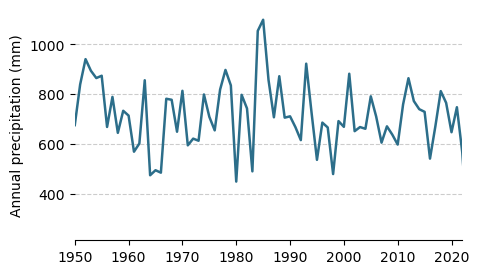

In [4]:

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(annual_tp["year"], annual_tp["tp_mm"], color="#2C6E8A", linewidth=1.8)
ax1.set_ylabel("Annual precipitation (mm)", fontsize = 10)
ax1.grid(axis="y", linestyle=":", alpha=0.4)
ax1.set_xlim(1950, 2022)
ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

path_to_save = project_root / "figures" / "pt_era5_land.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


## Annual precipitation anomaly

Precipitation anomalies are expressed as a percentage setting the reference period: 1951–1980.

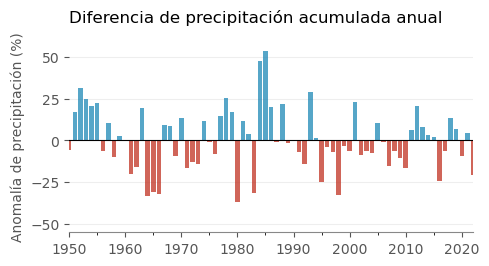

In [ ]:

baseline_period = annual_tp[(annual_tp["year"] >= 1951) & (annual_tp["year"] <= 1980)]
baseline_mean = baseline_period["tp_mm"].mean()

annual_tp["anomaly_pct"] = (annual_tp["tp_mm"] - baseline_mean) / baseline_mean * 100

fig,ax2 = plt.subplots( figsize=(5, 3))

colors = ["#C13121" if a < 0 else "#1E88B6" for a in annual_tp["anomaly_pct"]]
ax2.bar(annual_tp["year"], annual_tp["anomaly_pct"], color=colors, alpha=0.75)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Anomalía de precipitación (%)",fontsize = 10, color="#555")
ax2.xaxis.set_minor_locator(AutoMinorLocator(2)) 
ax2.yaxis.grid(True, color="#eee", linewidth=0.8)
ax2.tick_params(colors="#555")
ax2.set_axisbelow(True)

ax2.set_yticks([-50,-25,0,25,50])
ax2.set_ylim(-55,60)
ax2.tick_params(colors="#555")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_alpha(0)
ax2.spines["bottom"].set_color("#888")

ax2.set_title("Diferencia de precipitación acumulada anual",loc="left", y=1.05)


plt.xlim(1950,2022)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2) 
path_to_save = project_root / "figures" / "tp_1951-1980_bl_poopo.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()


Blue bars indicate rainfall years above the reference period average; red bars indicate deficits. 

## Potential evaporation (PEV)

To download monthly total evaporation, include the variable: (`potential_evaporation`) in the download step.


In [5]:
target_nc = data_raw / "era5_land_pev_poopo_monthly.nc"
cds_dataset = "reanalysis-era5-land-monthly-means"

start_year = 1950
end_year = 2025 

cds_request = {
    "product_type": "monthly_averaged_reanalysis",
    "variable": "potential_evaporation",
    "year": [str(y) for y in range(start_year, end_year + 1)],
    "month": [f"{m:02d}" for m in range(1, 13)],
    "time": "00:00",
    "format": "netcdf",
    "download_format": "unarchived",
    "area": poopo_region,  
}
# client = cdsapi.Client()
# client.retrieve(cds_dataset, cds_request, str(target_nc))

ERA5 stores evaporation as a negative flux (energy leaving the surface), so we multiply by -1000 to convert m → mm and flip to positive values.

In [6]:
pev = xr.open_dataset(target_nc)
# Monthly accumulation in mm
monthly_pev = cds.era5_monthly_accum(pev, "pev", -1000)
monthly_pev.to_csv( data_processed / "era5_land_pev_poopo_monthly.csv", index=False)
annual_pev = (monthly_pev.groupby(monthly_pev["valid_time"].dt.year)[f"pev_mm"].sum().reset_index().rename(columns={"valid_time":"year"}))
print(annual_pev.head())
annual_pev.to_csv( data_processed / "era5_land_pev_poopo_annual.csv", index=False)

   year       pev_mm
0  1950  1642.661043
1  1951  1616.641504
2  1952  1629.946845
3  1953  1648.940138
4  1954  1604.093700


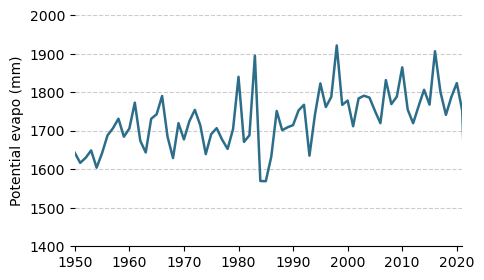

In [7]:

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(annual_pev["year"], annual_pev["pev_mm"], color="#2C6E8A", linewidth=1.8)
ax1.set_ylabel("Potential evapo (mm)", fontsize = 10)
ax1.grid(axis="y", linestyle=":", alpha=0.4)
ax1.set_xlim(1950, 2021)
ax1.set_ylim(1400, 2000)
ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

path_to_save = project_root / "figures" / "pev_era5_land.png"
plt.savefig(path_to_save, dpi=150, bbox_inches="tight")
plt.show()

From the analysis, I found there is a:
- Clear warming
- Slight decline of the annual precipitation
- Gradual increase on the evaporation, consitent with rising temperatures.